# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Problem Statement
Banks conduct marketing campaigns to promote term deposit subscriptions.  
The objective of this project is to build a machine learning model that predicts whether a customer will subscribe to a term deposit based on their profile and past interactions.

## Objective
- Load and explore the Bank Marketing dataset  
- Perform data preprocessing and encoding  
- Train classification models (Logistic Regression and Random Forest)  
- Evaluate models using Confusion Matrix, F1-Score, and ROC Curve  
- Explain model predictions using SHAP (Explainable AI)  
- Derive insights about customer behavior  


In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
import kagglehub

# Download latest version

path = kagglehub.dataset_download("alexkataev/bank-marketing-data-set")

print("Path to dataset files:", path)

/kaggle/input/datasets/alexkataev/bank-marketing-data-set/bank-additional-names.txt
/kaggle/input/datasets/alexkataev/bank-marketing-data-set/bank-additional-full.csv
Path to dataset files: /kaggle/input/datasets/alexkataev/bank-marketing-data-set


## 2. Environment Setup and Data Loading

In this section, we prepare the working environment by installing the required libraries and loading the dataset.


In [9]:
# Install SHAP for model interpretability
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score
import shap

# Download dataset
path = kagglehub.dataset_download("alexkataev/bank-marketing-data-set")
df = pd.read_csv(f"{path}/bank-additional-full.csv", sep=';')

# Quick look at the data
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Exploratory Data Analysis (EDA)

Understanding the distribution of our target variable and key features. 
Usually, bank marketing datasets are imbalanced, meaning there are significantly more "no" responses than "yes" responses for term deposit subscription.

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


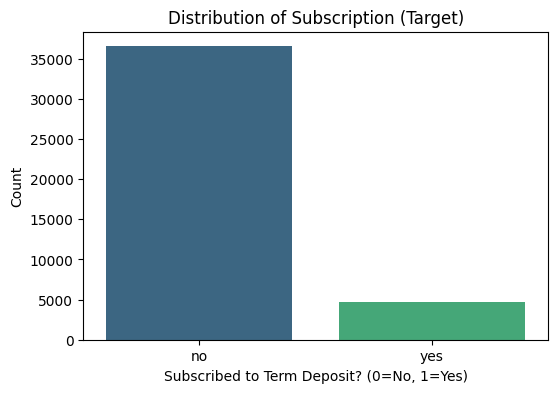

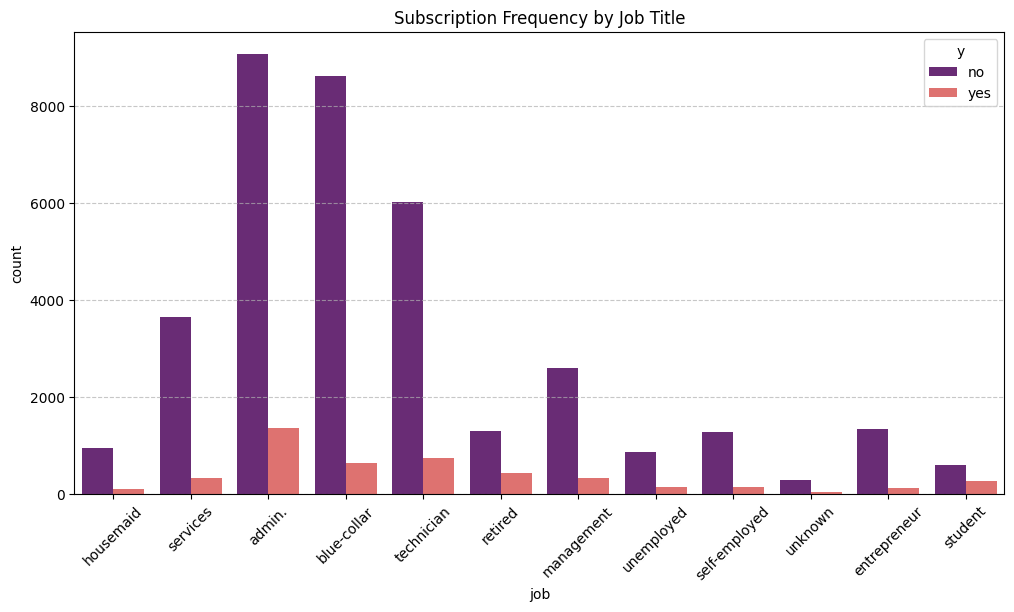

In [11]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Visualizing Target Variable Distribution
# Fixed: Added hue='y' and legend=False to resolve the FutureWarning
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df, hue='y', palette='viridis', legend=False)
plt.title('Distribution of Subscription (Target)')
plt.xlabel('Subscribed to Term Deposit? (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

# Visualizing Job vs Subscription
plt.figure(figsize=(12,6))
sns.countplot(x='job', hue='y', data=df, palette='magma')
plt.xticks(rotation=45)
plt.title('Subscription Frequency by Job Title')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4. Data Preprocessing and Encoding

Machine learning models require numerical input. We will use Label Encoding for the target variable and One-Hot Encoding for categorical features to ensure that the model does not assume a mathematical hierarchy between categories (such as job roles).

In [12]:
# Encode the target variable
le = LabelEncoder()
df['y'] = le.fit_transform(df['y']) # 'yes' becomes 1, 'no' becomes 0

# Identify categorical columns for One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object']).columns

# Create dummy variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define Features (X) and Target (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (Crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete. Training set size:", X_train.shape)

Preprocessing complete. Training set size: (32950, 53)


## 5. Model Building and Evaluation

We will train a Logistic Regression model as a baseline and a Random Forest model for improved accuracy and feature importance analysis.

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7310
           1       0.67      0.49      0.56       928

    accuracy                           0.92      8238
   macro avg       0.80      0.73      0.76      8238
weighted avg       0.91      0.92      0.91      8238



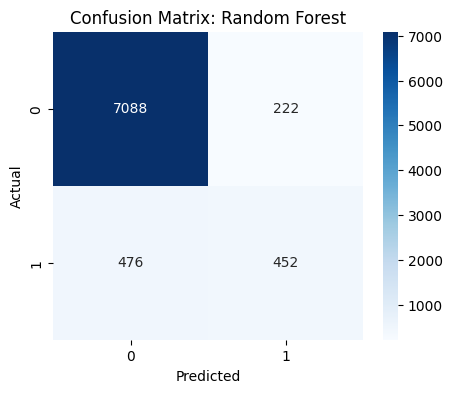

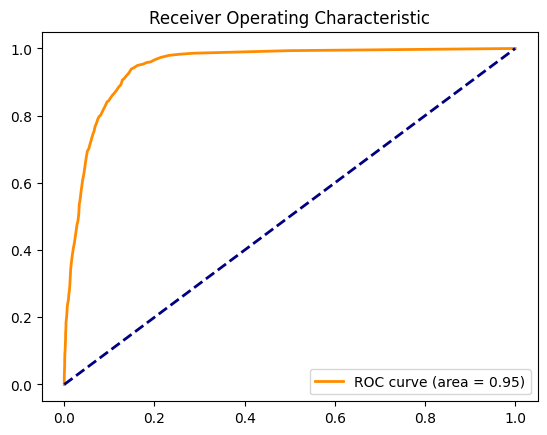

In [14]:
# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # RF handles unscaled data well
rf_preds = rf_model.predict(X_test)

# Evaluation - Classification Report
print("--- Random Forest Performance ---")
print(classification_report(y_test, rf_preds))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Random Forest')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## 6. Model Interpretability (Explainable AI - XAI)

Using SHAP (SHapley Additive exPlanations) to understand why the model made specific decisions for five individual customers.

Global Feature Importance (SHAP Summary):


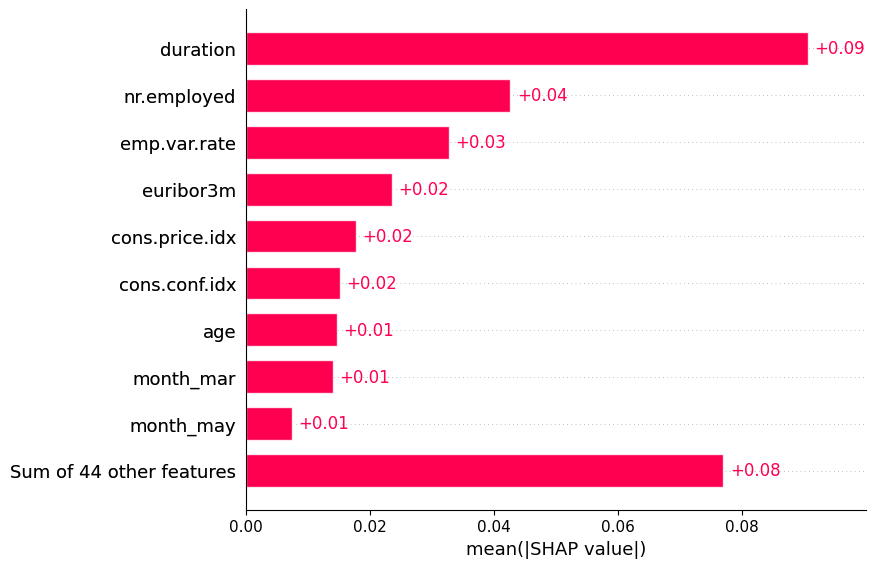


--- Individual Explanations for the first 5 customers ---

Customer Index 0 | Prediction: Will Not Subscribe (Prob: 0.00)


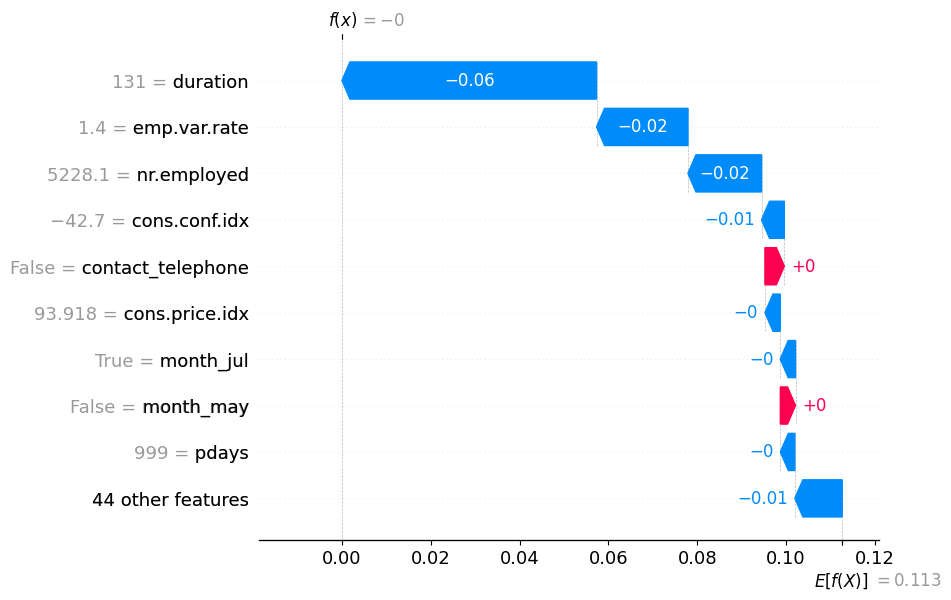


Customer Index 1 | Prediction: Will Not Subscribe (Prob: 0.09)


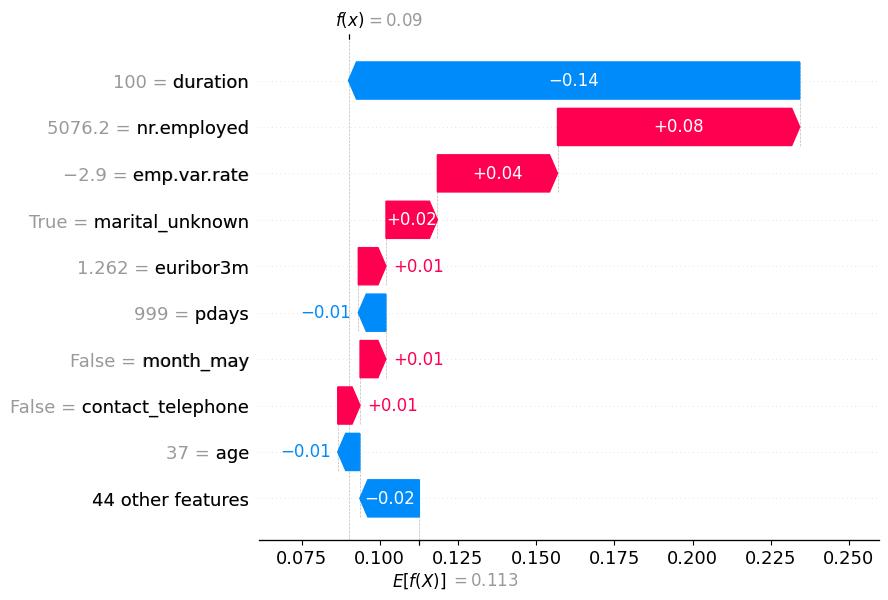


Customer Index 2 | Prediction: Will Not Subscribe (Prob: 0.30)


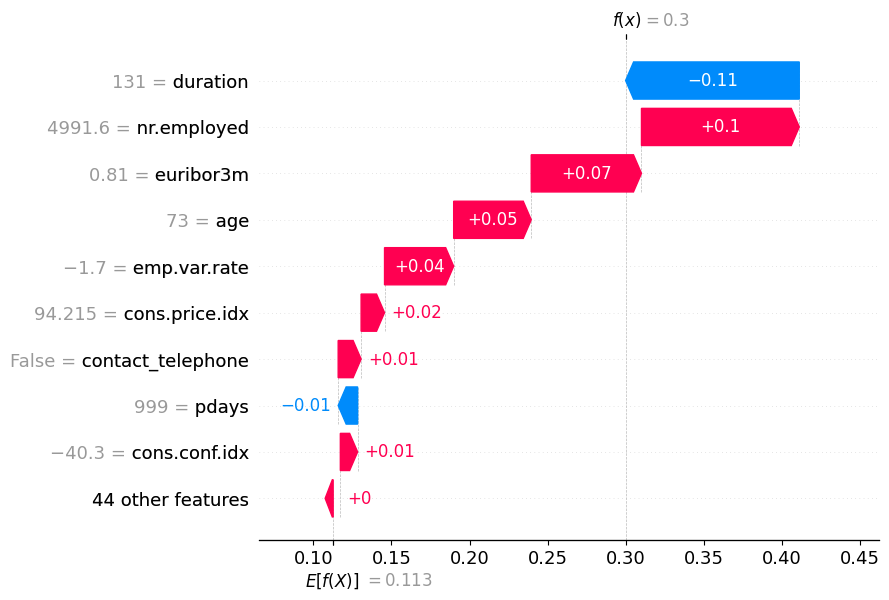


Customer Index 3 | Prediction: Will Not Subscribe (Prob: 0.00)


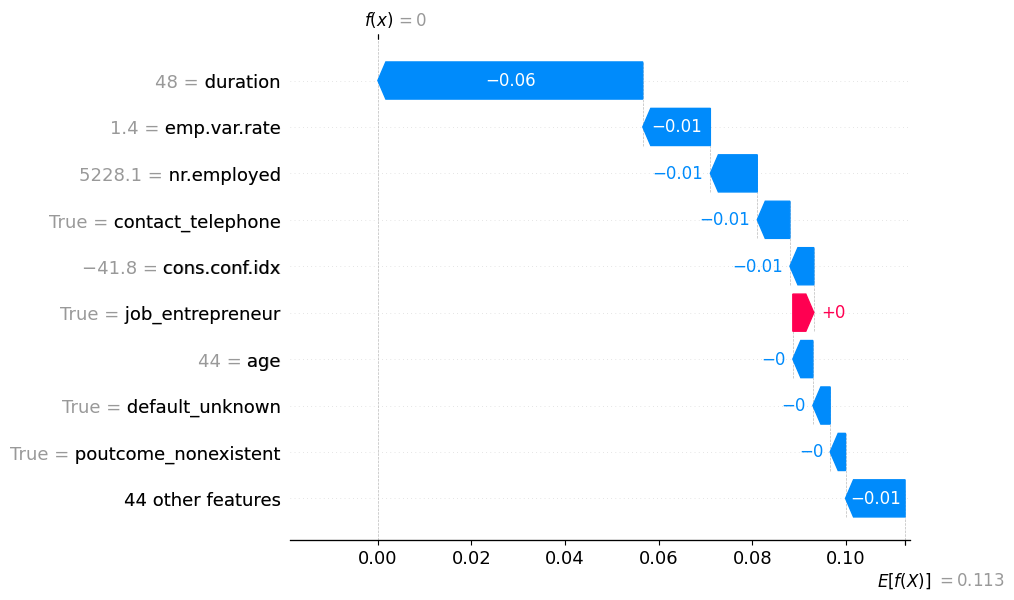


Customer Index 4 | Prediction: Will Not Subscribe (Prob: 0.29)


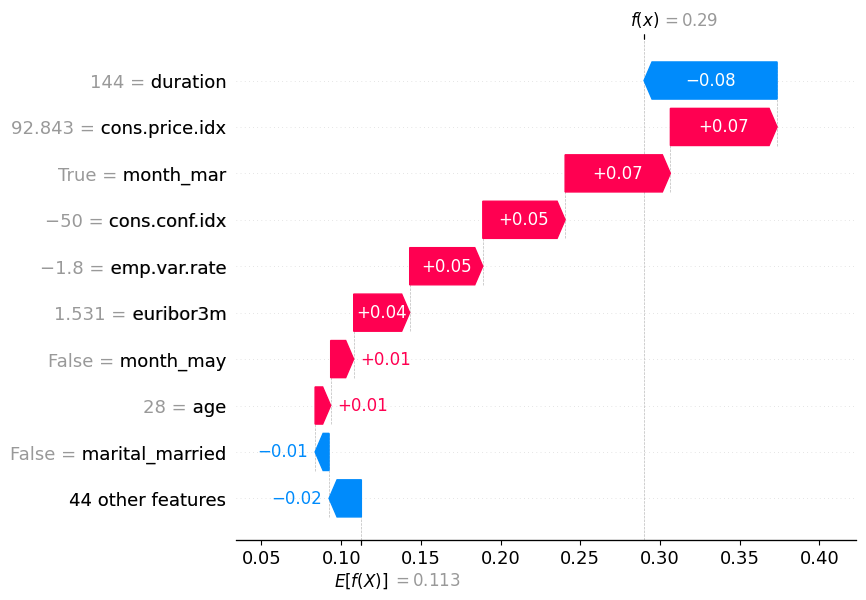

In [17]:
# 1. Initialize the SHAP Explainer
explainer = shap.TreeExplainer(rf_model)

# 2. Calculate SHAP values for a small sample
# Note: We use check_additivity=False sometimes if there are small rounding discrepancies
X_sample = X_test.iloc[:5] 
shap_values = explainer(X_sample)

# 3. Global Feature Importance Plot (Summary)
print("Global Feature Importance (SHAP Summary):")
shap.plots.bar(shap_values[:,:,1]) # Index 1 is the 'Yes' subscription class

# 4. Individual prediction explanations (Waterfall Plot)
print("\n--- Individual Explanations for the first 5 customers ---")

for i in range(5):
    prediction_prob = rf_model.predict_proba(X_sample.iloc[[i]])[0][1]
    prediction_label = "Will Subscribe" if prediction_prob > 0.5 else "Will Not Subscribe"
    
    print(f"\nCustomer Index {i} | Prediction: {prediction_label} (Prob: {prediction_prob:.2f})")
    
    # The waterfall plot is the best replacement for force_plot in static notebooks
    # .values[:,:,1] selects the SHAP values for the 'Yes' class
    shap.plots.waterfall(shap_values[i,:,1])

## 7. Conclusion and Insights

Based on the analysis and the SHAP values:

- **Duration:** The length of the last phone call is the most significant predictor. However, this information is only available after the call, making it less useful for predictive targeting before a campaign begins.

- **Economic Indicators:** Variables such as *euribor3m* (Euro Interbank Offered Rate)and *nr.employed* significantly impact the likelihood of subscription.

- **Recommendation:** The bank should prioritize customers who have been contacted fewer times in previous campaigns to reduce the risk of marketing fatigue and improve campaign effectiveness.